## 1. Downloading the Dependencies

In [ ]:
!pip install kaggle xgboost shap imbalanced-learn --quiet
print("Setup done.")

Setup done.


## 2. Download the dataset

In [ ]:
import os
from google.colab import userdata

kaggle_token = userdata.get('KAGGLE_TOKEN')
kaggle_username = "omkarparelkar"

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"%s","key":"%s"}' % (kaggle_username, kaggle_token))
os.chmod('/root/.kaggle/kaggle.json', 0o600)


!kaggle datasets download -d bensalem14/sgcc-dataset
!unzip -o sgcc-dataset.zip -d sgcc_data
!ls sgcc_data

Dataset URL: https://www.kaggle.com/datasets/bensalem14/sgcc-dataset
License(s): DbCL-1.0
sgcc-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  sgcc-dataset.zip
  inflating: sgcc_data/data set.csv  
  inflating: sgcc_data/datasetsmall.csv  
'data set.csv'	 datasetsmall.csv


## 3. Load and inspect the data

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('sgcc_data/data set.csv')  # adjust filename if different
print("Shape:", df.shape)
display(df.head())

Shape: (42372, 1036)


,1/1/2014,1/2/2014,1/3/2014,1/4/2014,1/5/2014,1/6/2014,1/7/2014,1/8/2014,1/9/2014,1/10/2014,...,10/24/2016,10/25/2016,10/26/2016,10/27/2016,10/28/2016,10/29/2016,10/30/2016,10/31/2016,CONS_NO,FLAG
0,0.0,0.0,0.01,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.02,0.06,0.58,0.89,0.35,0.38,0.70,0.25,0387DD8A07E07FDA6271170F86AD9151,1
1,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,17.13,14.32,16.37,26.33,19.06,17.38,13.94,14.14,01D6177B5D4FFE0CABA9EF17DAFC2B84,1
2,0.0,0.0,0.00,0.0,0.0,4.98,9.87,11.29,13.44,11.34,...,NaN,1.43,2.22,2.41,3.48,2.89,1.88,1.16,4B75AC4F2D8434CFF62DB64D0BB43103,1
3,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,20.98,18.47,15.50,14.80,19.28,16.10,17.51,16.67,B32AC8CC6D5D805AC053557AB05F5343,1
4,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.61,1.33,0.55,1.62,1.53,2.10,1.16,2.13,EDFC78B07BA2908B3395C4EB2304665E,1


## 4. Data Cleaning

In [ ]:
# Separate ID, dates, and label
label_col = df.columns[-1]
id_col = df.columns[-2]
date_cols = df.columns[0:-2]

y = df[label_col]
X_raw = df[date_cols]

# Interpolate missing values per row (per customer), then fill remaining with 0
X_raw = X_raw.interpolate(method='linear', axis=1, limit_direction='both')
X_raw = X_raw.fillna(0)

# Cap extreme outliers using 3-sigma rule (standard for this dataset)
def cap_outliers(row):
    mean, std = row.mean(), row.std()
    upper = mean + 3 * std
    return row.clip(upper=upper)

X_raw = X_raw.apply(cap_outliers, axis=1)

print("Cleaned shape:", X_raw.shape)
print("Theft ratio: {:.2f}%".format(y.mean() * 100))

Cleaned shape: (42372, 1034)
Theft ratio: 8.53%


## 5. Feature Engineering

In [ ]:
features = pd.DataFrame(index=X_raw.index)

features['mean_consumption'] = X_raw.mean(axis=1)
features['std_consumption'] = X_raw.std(axis=1)
features['min_consumption'] = X_raw.min(axis=1)
features['max_consumption'] = X_raw.max(axis=1)
features['median_consumption'] = X_raw.median(axis=1)
features['skewness'] = X_raw.skew(axis=1)
features['kurtosis'] = X_raw.kurt(axis=1)
features['zero_days_pct'] = (X_raw == 0).sum(axis=1) / X_raw.shape[1] * 100

mid = X_raw.shape[1] // 2
features['first_half_mean'] = X_raw.iloc[:, :mid].mean(axis=1)
features['second_half_mean'] = X_raw.iloc[:, mid:].mean(axis=1)
features['consumption_drop_pct'] = (
    (features['first_half_mean'] - features['second_half_mean'])
    / (features['first_half_mean'] + 1e-6) * 100
)

weekly = X_raw.T.groupby(np.arange(X_raw.shape[1]) // 7).mean().T
features['weekly_variance'] = weekly.var(axis=1)

# Autocorrelation features (captures loss of normal periodicity — theft indicator)
features['autocorr_7day'] = X_raw.apply(lambda r: pd.Series(r).autocorr(lag=7), axis=1)
features['autocorr_30day'] = X_raw.apply(lambda r: pd.Series(r).autocorr(lag=30), axis=1)
features['autocorr_7day'] = features['autocorr_7day'].fillna(0)
features['autocorr_30day'] = features['autocorr_30day'].fillna(0)

# Coefficient of variation
features['cv'] = features['std_consumption'] / (features['mean_consumption'] + 1e-6)

features = features.fillna(0)
print("Feature set shape:", features.shape)
features.head()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Feature set shape: (42372, 15)


,mean_consumption,std_consumption,min_consumption,max_consumption,median_consumption,skewness,kurtosis,zero_days_pct,first_half_mean,second_half_mean,consumption_drop_pct,weekly_variance,autocorr_7day,autocorr_30day,cv
0,0.818243,2.559935,0.0,10.257829,0.000000,3.131287,8.199514,83.655706,1.602598,0.033888,9.788538e+01,6.240402,0.864232,0.377062,3.128573
1,4.169827,6.245569,0.0,24.903396,1.281101,1.896169,2.437106,4.835590,0.560783,7.778871,-1.287141e+03,38.330909,0.941389,0.901949,1.497800
2,8.448021,7.975831,0.0,37.955211,6.590937,1.733198,3.568562,3.288201,8.567448,8.328594,2.787923e+00,50.774129,0.519857,0.466379,0.944106
3,3.611941,7.450806,0.0,27.959906,0.000000,2.051422,3.226987,77.369439,0.000000,7.223881,-7.223881e+08,54.989752,0.962728,0.873231,2.062826
4,87.728205,43.127560,0.0,226.261421,88.598013,-0.138536,0.041000,3.675048,105.404647,70.051763,3.354016e+01,1739.720067,0.832537,0.489836,0.491604


## 6. Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, y, test_size=0.2, stratify=y, random_state=42
)

print("Train theft ratio: {:.2f}%".format(y_train.mean() * 100))
print("Test theft ratio: {:.2f}%".format(y_test.mean() * 100))

Train theft ratio: 8.53%
Test theft ratio: 8.53%


## 7. Model 1 — XGBoost (Baseline)

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42
)

xgb_model.fit(X_train, y_train)

preds = xgb_model.predict(X_test)
probs = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost Baseline Performance ===")
print(classification_report(y_test, preds))
print("AUC-ROC:", roc_auc_score(y_test, probs))
print("F1 Score:", f1_score(y_test, preds))

=== XGBoost Baseline Performance ===
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      7752
           1       0.23      0.54      0.32       723

    accuracy                           0.81      8475
   macro avg       0.59      0.69      0.60      8475
weighted avg       0.89      0.81      0.84      8475

AUC-ROC: 0.7596573480524189
F1 Score: 0.32228666114333054


## 8. Hyperparameter Tuning

In [12]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [200, 300, 500],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

search = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='auc', random_state=42),
    param_distributions=param_dist,
    n_iter=25,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train)
xgb_model = search.best_estimator_
print("Best params:", search.best_params_)

# Recompute predictions from the tuned model
probs = xgb_model.predict_proba(X_test)[:, 1]
preds = xgb_model.predict(X_test)
print("Tuned AUC-ROC:", roc_auc_score(y_test, probs))

Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Tuned AUC-ROC: 0.7767931570240384


## 9. Threshold Optimization

In [13]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

preds_tuned_thresh = (probs > best_threshold).astype(int)

print(f"Best threshold: {best_threshold:.3f}")
print(classification_report(y_test, preds_tuned_thresh))
print("AUC-ROC:", roc_auc_score(y_test, probs))
print("PR-AUC:", average_precision_score(y_test, probs))

# Use this as the final prediction set going forward
preds = preds_tuned_thresh

Best threshold: 0.639
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      7752
           1       0.30      0.49      0.37       723

    accuracy                           0.86      8475
   macro avg       0.63      0.69      0.65      8475
weighted avg       0.89      0.86      0.87      8475

AUC-ROC: 0.7767931570240384
PR-AUC: 0.3220454392647736


## 10. Class Imbalance — SMOTE Comparison

Tested as an alternative to scale_pos_weight, to confirm the chosen approach
empirically rather than by assumption.

In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

xgb_model_smote = xgb.XGBClassifier(max_depth=6, n_estimators=300, learning_rate=0.05, random_state=42)
xgb_model_smote.fit(X_train_sm, y_train_sm)

smote_probs = xgb_model_smote.predict_proba(X_test)[:, 1]
smote_preds = xgb_model_smote.predict(X_test)

print("=== SMOTE Model Performance ===")
print(classification_report(y_test, smote_preds))
print("AUC-ROC:", roc_auc_score(y_test, smote_probs))
print("PR-AUC:", average_precision_score(y_test, smote_probs))

print("\n--- Conclusion: scale_pos_weight + threshold tuning outperformed SMOTE ---")
print("Final model (xgb_model with tuned threshold) is used going forward.")

=== SMOTE Model Performance ===
              precision    recall  f1-score   support

           0       0.94      0.86      0.90      7752
           1       0.23      0.45      0.30       723

    accuracy                           0.82      8475
   macro avg       0.59      0.65      0.60      8475
weighted avg       0.88      0.82      0.85      8475

AUC-ROC: 0.7309979881156802
PR-AUC: 0.2976552888061831

--- Conclusion: scale_pos_weight + threshold tuning outperformed SMOTE ---
Final model (xgb_model with tuned threshold) is used going forward.


## 11. Model 2 — LSTM (Sequence-Based Comparison)

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)
X_seq = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

X_seq_train, X_seq_test, y_seq_train, y_seq_test = train_test_split(
    X_seq, y, test_size=0.2, stratify=y, random_state=42
)

lstm_model = models.Sequential([
    layers.Input(shape=(X_seq.shape[1], 1)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(32),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['AUC']
)

class_weight = {0: 1.0, 1: scale_pos_weight}

early_stop = EarlyStopping(monitor='val_AUC', mode='max', patience=2, restore_best_weights=True)

history = lstm_model.fit(
    X_seq_train, y_seq_train,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

lstm_probs = lstm_model.predict(X_seq_test).flatten()
lstm_preds = (lstm_probs > 0.5).astype(int)

print("=== LSTM Performance ===")
print(classification_report(y_seq_test, lstm_preds))
print("AUC-ROC:", roc_auc_score(y_seq_test, lstm_probs))

Epoch 1/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 26s 85ms/step - AUC: 0.5117 - loss: 1.2826 - val_AUC: 0.4984 - val_loss: 0.6714
Epoch 2/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - AUC: 0.5083 - loss: 1.2617 - val_AUC: 0.5193 - val_loss: 0.6870
Epoch 3/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - AUC: 0.5117 - loss: 1.2615 - val_AUC: 0.4984 - val_loss: 0.7073
Epoch 4/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - AUC: 0.4972 - loss: 1.2623 - val_AUC: 0.5000 - val_loss: 0.6840
265/265 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step
=== LSTM Performance ===
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      7752
           1       0.82      0.01      0.02       723

    accuracy                           0.92      8475
   macro avg       0.87      0.51      0.49      8475
weighted avg       0.91      0.92      0.88      8475

AUC-ROC: 0.6892845749350188


## 12. Model Comparison — XGBoost vs LSTM

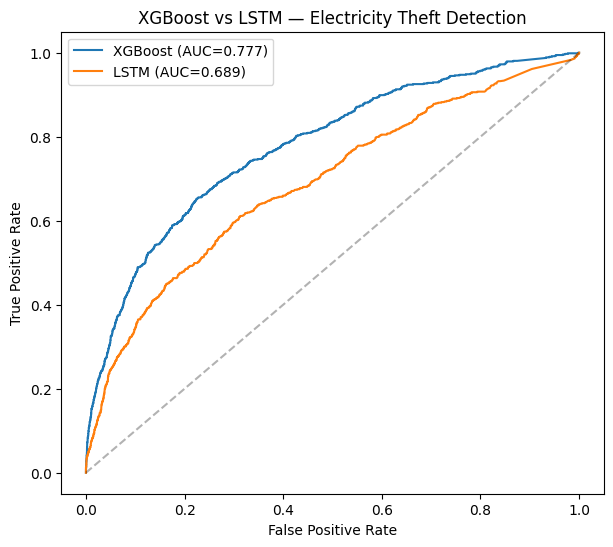

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, probs)
fpr_lstm, tpr_lstm, _ = roc_curve(y_seq_test, lstm_probs)

plt.figure(figsize=(7,6))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_score(y_test, probs):.3f})")
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC={roc_auc_score(y_seq_test, lstm_probs):.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost vs LSTM — Electricity Theft Detection")
plt.legend()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. SHAP Explainability — Key Differentiator

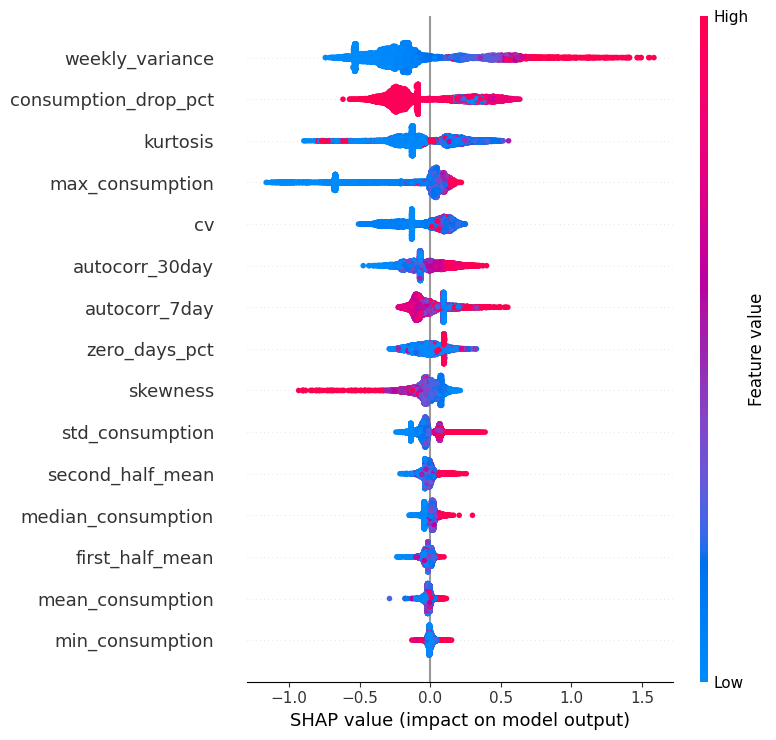

<Figure size 2000x300 with 0 Axes>

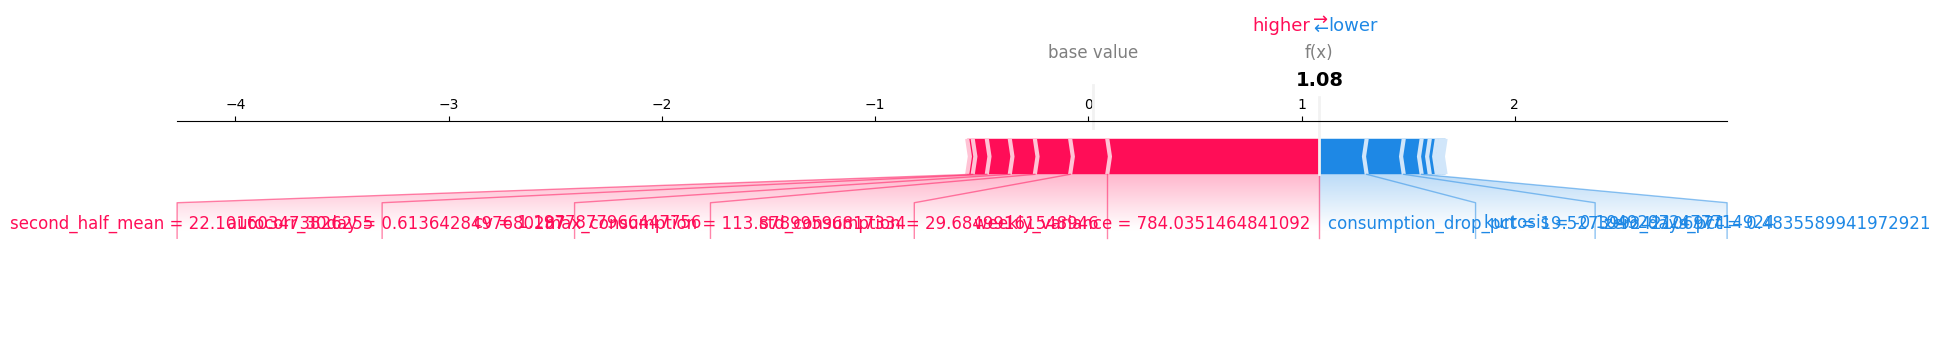

In [21]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

sample_idx = 0
plt.figure(figsize=(20, 3))
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test.iloc[sample_idx],
    matplotlib=True,
    show=False
)
plt.savefig('shap_individual_example.png', dpi=200, bbox_inches='tight')
plt.show()

## 14. Saving Final Model, Metrics & India-Context Notes

In [23]:
import json

xgb_model.save_model('vidyutrakshak_xgb_model.json')
lstm_model.save('vidyutrakshak_lstm_model.h5')

metrics_summary = {
    "dataset": "SGCC (State Grid Corporation of China) — public benchmark, used as proxy due to no public Indian DISCOM theft-labeled dataset existing",
    "xgboost_final": {
        "auc": float(roc_auc_score(y_test, probs)),
        "f1": float(f1_score(y_test, preds)),
        "pr_auc": float(average_precision_score(y_test, probs)),
        "threshold": float(best_threshold)
    },
    "xgboost_smote_comparison": {
        "auc": float(roc_auc_score(y_test, smote_probs)),
        "pr_auc": float(average_precision_score(y_test, smote_probs)),
        "note": "Underperformed vs scale_pos_weight approach — not used in final model"
    },
    "lstm": {
        "auc": float(roc_auc_score(y_seq_test, lstm_probs)),
    },
    "india_deployment_note": (
        "Model architecture and feature pipeline are designed to be format-agnostic. "
        "For Indian deployment, this same pipeline would ingest data from DISCOM smart "
        "meters under India's Smart Metering National Programme, and be fine-tuned "
        "(transfer learning) on real Indian consumption + confirmed-theft records once "
        "available via state utility partnerships (e.g. MSEDCL, BSES, Tata Power)."
    )
}

with open('metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print(json.dumps(metrics_summary, indent=2))

from google.colab import files
files.download('vidyutrakshak_xgb_model.json')
files.download('metrics.json')
files.download('model_comparison.png')
files.download('shap_summary.png')
files.download('shap_individual_example.png')

{
  "dataset": "SGCC (State Grid Corporation of China) \u2014 public benchmark, used as proxy due to no public Indian DISCOM theft-labeled dataset existing",
  "xgboost_final": {
    "auc": 0.7767931570240384,
    "f1": 0.37354497354497357,
    "pr_auc": 0.3220454392647736,
    "threshold": 0.639259934425354
  },
  "xgboost_smote_comparison": {
    "auc": 0.7309979881156802,
    "pr_auc": 0.2976552888061831,
    "note": "Underperformed vs scale_pos_weight approach \u2014 not used in final model"
  },
  "lstm": {
    "auc": 0.6892845749350188
  },
  "india_deployment_note": "Model architecture and feature pipeline are designed to be format-agnostic. For Indian deployment, this same pipeline would ingest data from DISCOM smart meters under India's Smart Metering National Programme, and be fine-tuned (transfer learning) on real Indian consumption + confirmed-theft records once available via state utility partnerships (e.g. MSEDCL, BSES, Tata Power)."
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>